In [1]:
import os

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import polars as pl
from matplotlib.colors import BoundaryNorm, ListedColormap
from mlflow.tracking import MlflowClient

plt.style.use("seaborn-v0_8-paper")

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")
assert MLFLOW_TRACKING_URI is not None
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

In [2]:
def get_metric_by_step(run_id: str, metric_key: str) -> pl.DataFrame:
    client = MlflowClient()
    metric_history = client.get_metric_history(run_id=run_id, key=metric_key)
    return pl.DataFrame(
        [
            {
                "run_id": run_id,
                "step": m.step,
                "timestamp": pd.to_datetime(m.timestamp, unit="ms"),
                "value": m.value,
            }
            for m in metric_history
        ]
    ).sort("step")


def get_labels_by_step(run_id: str) -> pl.DataFrame:
    client = MlflowClient()
    return pl.concat(
        [
            pl.read_json(client.download_artifacts(run_id=run_id, path=f"ablation_ces_{step}.json")).select(
                pl.lit(step).alias("step"), pl.all()
            )
            for step in range(33)
        ],
        how="diagonal_relaxed",
    )

In [3]:
baseline_run_ids = [
    "b147567ae49344e3ba9d45577f4edd80",
    "a0a4158fb9d9488fb0f544638fa0dd70",
    "762a6c007b1749209d72b69aa6b80eea",
]
proposal_run_ids = [
    "b5fff9f1325040cfb2781a4a48c3d6ba",
    "1e84169fbec744ee9755eb12e4a616a3",
    "db89852f835c49dfa1038919a60c60af",
]

### metric

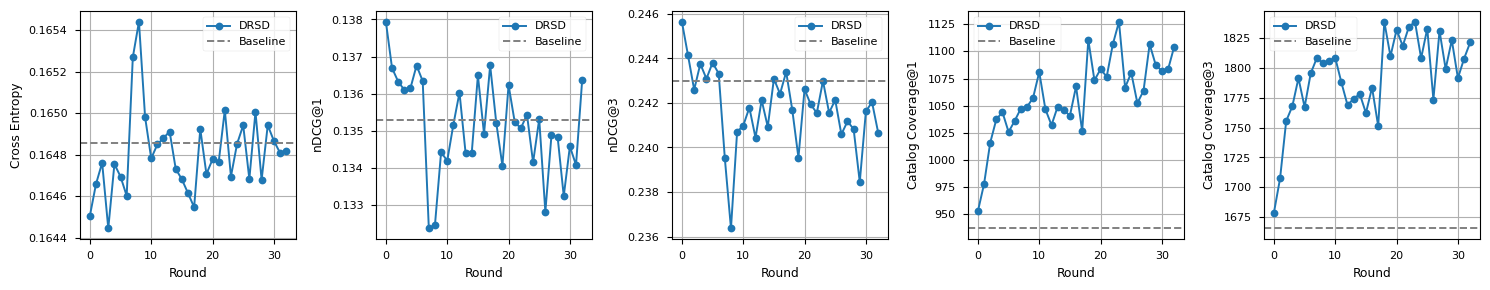

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

baseline_df = (
    pl.concat([get_metric_by_step(run_id, "test_cross_entropy") for run_id in baseline_run_ids], how="vertical")
    .group_by("step")
    .agg(pl.col("value").mean(), pl.col("run_id"))
    .sort("step")
)
assert baseline_df.get_column("run_id").list.len().min() == 3
assert baseline_df.get_column("run_id").list.len().max() == 3

proposal_df = (
    pl.concat([get_metric_by_step(run_id, "test_cross_entropy") for run_id in proposal_run_ids], how="vertical")
    .group_by("step")
    .agg(pl.col("value").mean(), pl.col("run_id"))
    .sort("step")
)
assert proposal_df.get_column("run_id").list.len().min() == 3
assert proposal_df.get_column("run_id").list.len().max() == 3

axes[0].plot(proposal_df.get_column("step"), proposal_df.get_column("value"), marker="o", label="DRSD")
axes[0].axhline(baseline_df["value"][0], color="gray", linestyle="--", label="Baseline")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Cross Entropy")
axes[0].grid()
axes[0].legend()

for i, metric_key in enumerate(["test_ndcg_1", "test_ndcg_3", "test_coverage_1", "test_coverage_3"]):
    baseline_df = (
        pl.concat([get_metric_by_step(run_id, metric_key) for run_id in baseline_run_ids], how="vertical")
        .group_by("step")
        .agg(pl.col("value").mean(), pl.col("run_id"))
        .sort("step")
    )
    assert baseline_df.get_column("run_id").list.len().min() == 3
    assert baseline_df.get_column("run_id").list.len().max() == 3

    proposal_df = (
        pl.concat([get_metric_by_step(run_id, metric_key) for run_id in proposal_run_ids], how="vertical")
        .group_by("step")
        .agg(pl.col("value").mean(), pl.col("run_id"))
        .sort("step")
    )
    assert proposal_df.get_column("run_id").list.len().min() == 3
    assert proposal_df.get_column("run_id").list.len().max() == 3

    ax = axes[i + 1]

    ax.plot(proposal_df.get_column("step"), proposal_df.get_column("value"), marker="o", label="DRSD")
    ax.axhline(baseline_df["value"][0], color="gray", linestyle="--", label="Baseline")
    ax.set_xlabel("Round")
    ax.set_ylabel(
        f"{ {'recall': 'Recall', 'ndcg': 'nDCG', 'coverage': 'Catalog Coverage'}[metric_key.split('_')[1]] }@${
            metric_key.split('_')[-1]
        }$"
    )
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.savefig("metrics.pdf", dpi=300)
plt.show()

### label activity map

In [5]:
df = get_labels_by_step(proposal_run_ids[0]).drop(["Unknown"])
df

step,Background,Update,Alternative,Cross-Domain Analogy,Co-Occurring Events,Cross-League Analogy,Thematic Parallel,Parallel Incident,Complementary Advice,Contrasting Realities,Parallel Recalls,Contrasting Outcomes,Aspirational to Practical,Parallel Tragedies,Generational Shift,Seasonal Transition,Parallel Disasters,Cross-Sport Analogy,Parallel Career Moves,Cross-Sport Comparison,Business Closure,Cross-Sport Performance,Co-Category Exploration,Comparison
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,i64
0,-0.006587,0.009952,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1,0.004265,0.004668,0.003873,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2,-0.009379,0.004264,0.000608,0.014107,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
3,-0.0121,0.010073,0.00088,0.0027,0.001835,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4,-0.005675,0.001315,0.001875,0.001047,0.002644,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
28,null,0.004463,0.001348,null,null,0.005239,null,null,0.003503,null,null,null,null,null,null,0.001431,0.006712,-0.016899,null,0.004636,0,null,null,null
29,null,0.003304,0.00306,null,null,0.008705,null,null,0.005259,null,null,null,null,null,null,0.012911,0.00781,null,null,0.011026,0,0.0,null,null
30,null,0.008009,0.002821,null,null,0.008637,null,null,0.00352,null,null,null,null,null,null,0.006572,0.009513,null,null,0.006711,null,0.005088,0.002174,null


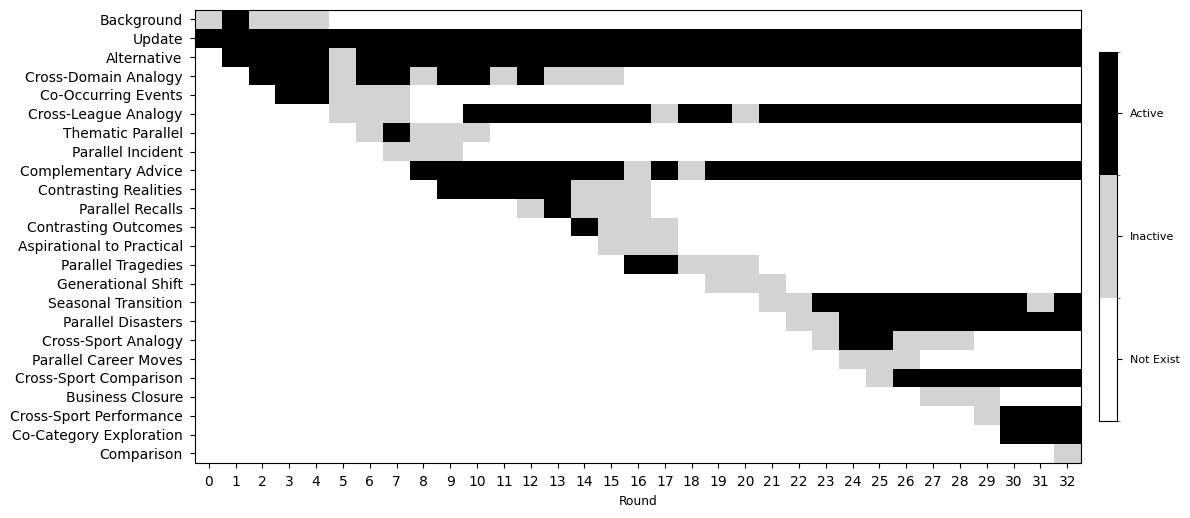

In [6]:
# Draw a heatmap of label liveness status (step on x-axis, label on y-axis)

plot_df = df.sort("step")
steps = plot_df.get_column("step").to_list()
label_cols = plot_df.columns[1:]

# For readability, sort labels by the step at which they first appear
label_first_seen = []
for col in label_cols:
    s = plot_df.get_column(col)
    first_idx = next((i for i, v in enumerate(s.to_list()) if v is not None), len(steps))
    label_first_seen.append((col, first_idx))
label_cols = [c for c, _ in sorted(label_first_seen, key=lambda x: x[1])]

# Encode status as an integer: -1=null (not yet existing), 0=inactive, 1=active
status = np.empty((len(label_cols), len(steps)), dtype=int)
for i, col in enumerate(label_cols):
    vals = plot_df.get_column(col).to_list()
    status[i, :] = [(-1 if v is None else (1 if v > 0 else 0)) for v in vals]

cmap = ListedColormap(["#ffffff", "lightgray", "black"])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

fig_h = max(4, min(0.22 * len(label_cols), 24))
fig, ax = plt.subplots(figsize=(12, fig_h))
im = ax.imshow(status, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)

ax.set_xlabel("Round")
ax.set_xticks(np.arange(len(steps)))
ax.set_xticklabels(steps)

ax.set_yticks(np.arange(len(label_cols)))
ax.set_yticklabels(label_cols)

cbar = fig.colorbar(im, ax=ax, ticks=[-1, 0, 1], fraction=0.02, pad=0.02)
cbar.ax.set_yticklabels(["Not Exist", r"Inactive", r"Active"])

ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("label_activity_map.pdf", dpi=300)
plt.show()